# DATA EXPLORATION NOTEBOOK
This notebook is the first exploratory analysis of the QuantRiskLab project.

The objective is to load, inspect, clean and visualize historical market data for a selected group of financial assets.

## Main goals

- Load adjusted close price data
- Inspect the dataset structure
- Check missing values
- Calculate simple and logarithmic returns
- Create initial visualizations
- Prepare the data for future risk analysis

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "../data/processed/adjusted_close_prices.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-02,24.192604,114.080002,46.274319,39.681740,0.482423,169.687851,93.001534,57.145546
2015-01-05,23.511057,115.800003,44.837727,39.316833,0.474275,166.623322,94.462395,55.581928
2015-01-06,23.513271,117.120003,43.675137,38.739761,0.459896,165.053909,96.164375,55.286461
2015-01-07,23.842979,116.430000,43.741783,39.231960,0.458697,167.110657,95.974419,55.846649
2015-01-08,24.759083,115.940002,44.719254,40.386105,0.475952,170.076096,94.703453,56.776196


In [28]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2887 entries, 2015-01-02 to 2026-06-26
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2887 non-null   float64
 1   GLD     2887 non-null   float64
 2   JPM     2887 non-null   float64
 3   MSFT    2887 non-null   float64
 4   NVDA    2887 non-null   float64
 5   SPY     2887 non-null   float64
 6   TLT     2887 non-null   float64
 7   XOM     2887 non-null   float64
dtypes: float64(8)
memory usage: 203.0 KB


In [29]:
prices.describe()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
count,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000,2887.000000
mean,113.113848,176.909151,126.595191,213.892236,39.547563,351.370619,99.782797,71.241855
std,80.025037,79.610940,74.332683,145.742254,58.609890,155.301658,15.702697,29.252846
min,20.565865,100.500000,40.268795,34.284485,0.458697,154.161636,73.974892,23.823555
25%,37.276920,121.250000,76.880417,76.209335,3.875440,223.520203,88.133686,52.061506
50%,111.904594,161.979996,104.126556,201.960846,12.422424,312.718414,95.169754,56.742496
75%,173.136215,183.659996,145.070358,325.133423,43.330591,432.758667,106.785076,97.756516
max,315.200012,495.899994,335.119995,538.658569,235.465576,757.618225,143.226501,170.313995


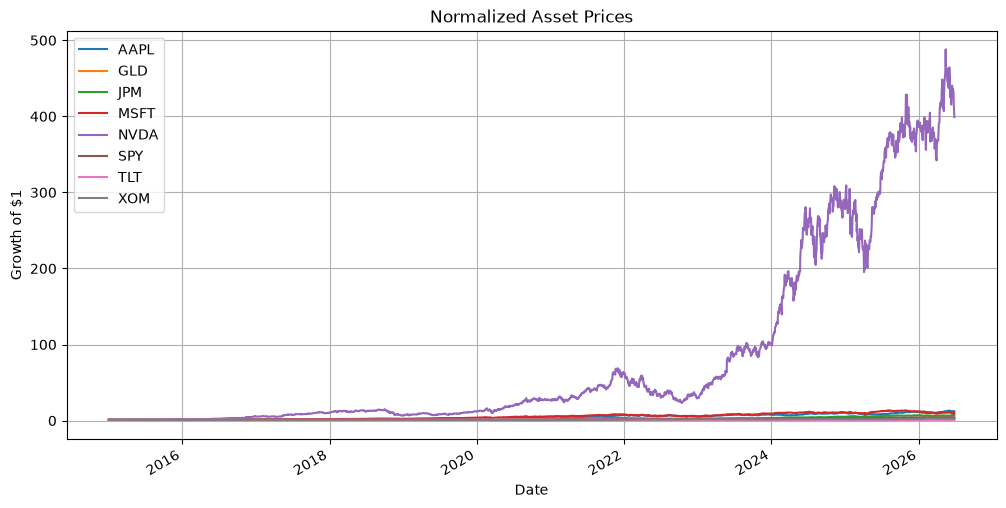

In [30]:
normalized_prices = prices / prices.iloc[0]

normalized_prices.plot(figsize=(12, 6))
plt.title("Normalized Asset Prices")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [31]:
returns = pd.read_csv(
    "../data/processed/simple_returns.csv",
    index_col=0,
    parse_dates=True,
)

returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,-0.028172,0.015077,-0.031045,-0.009196,-0.016890,-0.018060,0.015708,-0.027362
2015-01-06,0.000094,0.011399,-0.025929,-0.014677,-0.030318,-0.009419,0.018018,-0.005316
2015-01-07,0.014022,-0.005891,0.001526,0.012705,-0.002605,0.012461,-0.001975,0.010132
2015-01-08,0.038422,-0.004209,0.022346,0.029418,0.037618,0.017745,-0.013243,0.016645
2015-01-09,0.001072,0.011385,-0.017387,-0.008405,0.004028,-0.008014,0.010953,-0.001410


In [32]:
daily_volatility = returns.std().sort_values(ascending=False)
daily_volatility

NVDA    0.030427
AAPL    0.018095
XOM     0.017339
MSFT    0.017164
JPM     0.017034
SPY     0.011119
GLD     0.010107
TLT     0.009355
dtype: float64

In [33]:
correlation_matrix = returns.corr()
correlation_matrix

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
AAPL,1.000000,0.027407,0.416765,0.639003,0.518389,0.738677,-0.107892,0.288813
GLD,0.027407,1.000000,-0.075907,0.029611,0.037143,0.067385,0.258214,0.038872
JPM,0.416765,-0.075907,1.000000,0.421691,0.336250,0.711789,-0.319088,0.513799
MSFT,0.639003,0.029611,0.421691,1.000000,0.589152,0.763119,-0.115714,0.248815
NVDA,0.518389,0.037143,0.336250,0.589152,1.000000,0.646706,-0.073238,0.183289
SPY,0.738677,0.067385,0.711789,0.763119,0.646706,1.000000,-0.173682,0.504959
TLT,-0.107892,0.258214,-0.319088,-0.115714,-0.073238,-0.173682,1.000000,-0.239929
XOM,0.288813,0.038872,0.513799,0.248815,0.183289,0.504959,-0.239929,1.000000


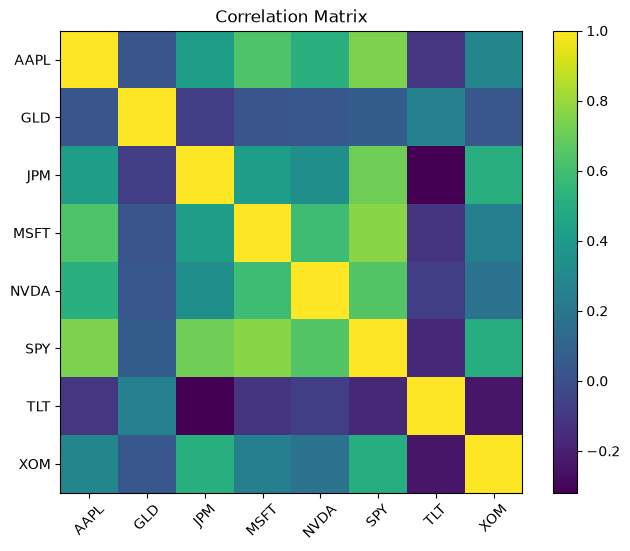

In [34]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Correlation Matrix")
plt.show()